In [ ]:
# Capstonr Project
#Random Forest Feature Stability Analysis

In [ ]:
# Load the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import warnings
warnings.filterwarnings('ignore')

In [36]:
# Load the dataset
df = pd.read_csv("METABRIC_RNA_Mutation.csv", low_memory=False)

print(df.shape)
df.head()

(1904, 693)


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [37]:
# Target and Features
y = df["overall_survival"].reset_index(drop=True)

X = df.iloc[:, 31:].copy()

print(X.shape, y.shape)

(1904, 662) (1904,)


In [38]:
# Data preprocessing
from sklearn.impute import SimpleImputer

# Convert to numeric
X = X.apply(pd.to_numeric, errors='coerce')

print("Missing values:", X.isnull().sum().sum())

# Impute missing values
imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("Clean dataset:", X.shape)

Missing values: 9739
Clean dataset: (1904, 662)


In [39]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
# Random Forest Base Model

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

base_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(base_importance.head(10))

hsd17b11    0.006504
jak1        0.005916
gsk3b       0.005214
stat5a      0.004827
jak2        0.004804
flt3        0.004566
kit         0.004492
cdkn2c      0.004328
smad4       0.004278
casp8       0.004018
dtype: float64


In [ ]:
# Repeated Random Forest (30 times)
n_runs = 30

feature_importances = pd.DataFrame(
    0.0,
    index=range(n_runs),
    columns=X.columns
)

for i in range(n_runs):
    X_resampled, y_resampled = resample(X_train, y_train, random_state=i) 
    
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=i,
        n_jobs=-1
    )
    
    rf.fit(X_resampled, y_resampled)
    
    feature_importances.loc[i] = rf.feature_importances_
    
print(feature_importances)

       brca1     brca2     palb2      pten      tp53       atm      cdh1  \
0   0.001902  0.001952  0.002065  0.002003  0.002664  0.002173  0.002004   
1   0.001429  0.001623  0.001746  0.001287  0.001529  0.001830  0.002351   
2   0.001993  0.001948  0.002098  0.001812  0.002176  0.001670  0.001138   
3   0.001897  0.001834  0.001910  0.001152  0.002554  0.001612  0.001679   
4   0.003805  0.001787  0.002521  0.001492  0.002390  0.001637  0.001643   
5   0.002093  0.002611  0.002501  0.001362  0.002113  0.001787  0.001241   
6   0.001277  0.001663  0.001960  0.001710  0.002635  0.001758  0.002114   
7   0.002163  0.001980  0.001798  0.001440  0.002122  0.001481  0.001871   
8   0.002770  0.002268  0.001787  0.001812  0.002227  0.002236  0.001612   
9   0.001965  0.002180  0.001189  0.001490  0.002240  0.001359  0.001827   
10  0.001990  0.001480  0.001116  0.002467  0.001462  0.001453  0.002079   
11  0.001436  0.001926  0.001441  0.001903  0.001992  0.001472  0.002442   
12  0.002105

In [58]:
rf_mean = feature_importances.mean()
rf_std = feature_importances.std()
rf_cv = (rf_std / rf_mean).replace([np.inf, -np.inf], np.nan).fillna(0)
rf_frequency = (feature_importances > 0).mean()

In [78]:
stability_df = pd.DataFrame({
    "Mean_Importance": rf_mean,
    "Std": rf_std,
    "CV": rf_cv,
    "Frequency": rf_frequency
}).sort_values("Mean_Importance", ascending=False)

print(stability_df.head(20))

top10_ = stability_df.head(5)
top10_.round(3).to_csv("top5_table.csv")


          Mean_Importance       Std        CV  Frequency
cdkn2c           0.005019  0.001842  0.366960        1.0
hsd17b11         0.005000  0.001273  0.254609        1.0
gsk3b            0.004982  0.001755  0.352201        1.0
jak1             0.004921  0.001295  0.263235        1.0
flt3             0.004863  0.001447  0.297494        1.0
kit              0.004595  0.001602  0.348713        1.0
ncoa3            0.004524  0.001506  0.332965        1.0
afdn             0.004394  0.001107  0.251890        1.0
jak2             0.004115  0.001552  0.377203        1.0
smad4            0.003981  0.001349  0.338798        1.0
casp8            0.003907  0.001356  0.347107        1.0
lamb3            0.003800  0.001213  0.319200        1.0
arid5b           0.003703  0.001349  0.364309        1.0
myc              0.003655  0.001676  0.458556        1.0
spry2            0.003575  0.001261  0.352887        1.0
stat5a           0.003572  0.001134  0.317384        1.0
rps6kb2          0.003515  0.00

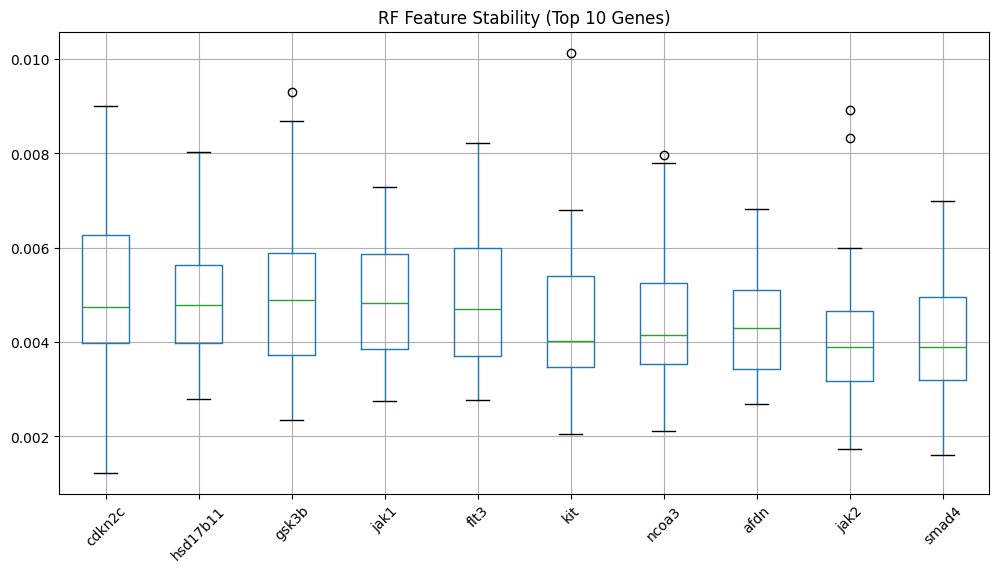

In [70]:
#Boxplot (stability across runs)
import matplotlib.pyplot as plt
import seaborn as sns

top10 = stability_df.index[:10]

plt.figure(figsize=(12,6))

box = feature_importances[top10].boxplot()

colors = sns.color_palette("Set3", len(top10))

# Apply colors correctly
for patch, color in zip(box.artists, colors):
    patch.set_facecolor(color)

plt.title("RF Feature Stability (Top 10 Genes)")
plt.xticks(rotation=45)
plt.show()

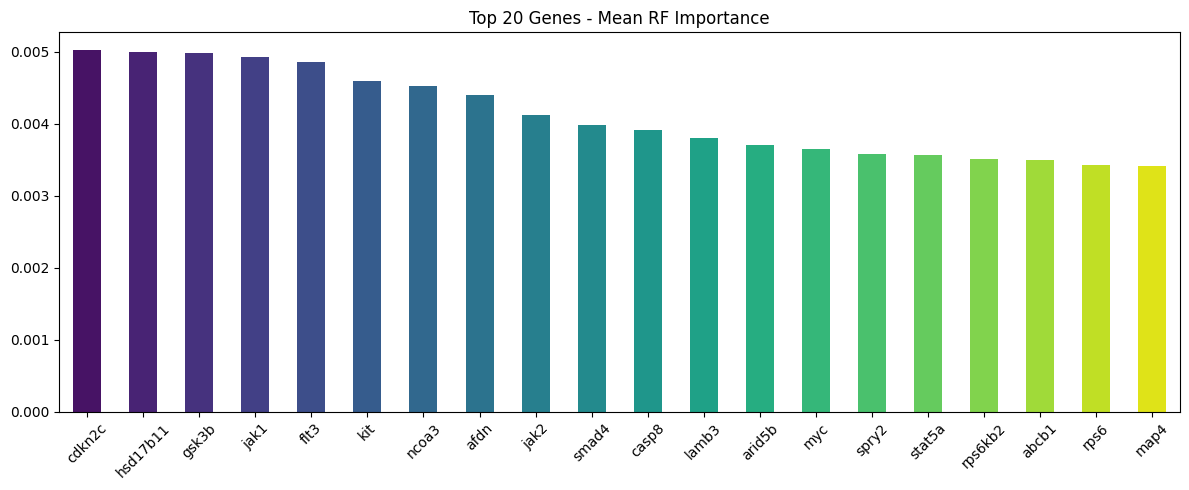

In [73]:
top20 = stability_df["Mean_Importance"].head(20)

colors = sns.color_palette("viridis", len(top20))

top20.plot(kind="bar", figsize=(12,5), color=colors)

plt.title("Top 20 Genes - Mean RF Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

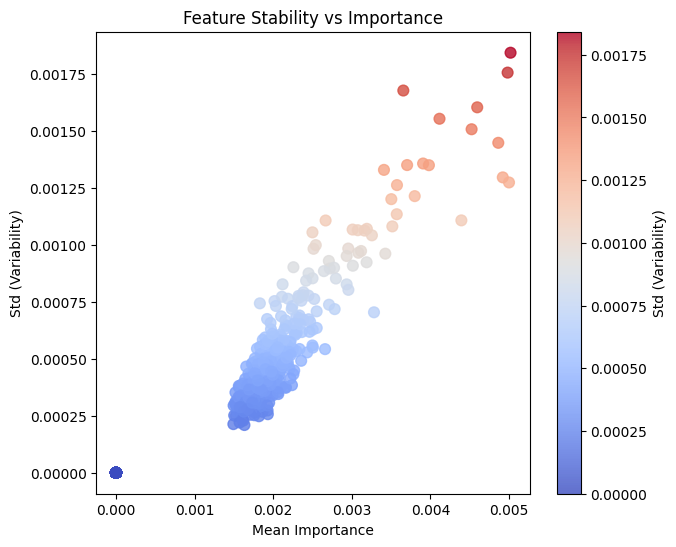

In [74]:
#Stability Analysis vs Variability
plt.figure(figsize=(7,6))

plt.scatter(
    rf_mean,
    rf_std,
    c=rf_std,
    cmap="coolwarm",
    s=60,
    alpha=0.8
)

plt.xlabel("Mean Importance")
plt.ylabel("Std (Variability)")
plt.title("Feature Stability vs Importance")

plt.colorbar(label="Std (Variability)")
plt.show()

In [63]:
# Stability Analysis
# Frequency of top 10 features across runs
top_k = int(0.1 * X.shape[1])

ranks = feature_importances.rank(axis=1, ascending=False)

frequency_stability = (ranks <= top_k).sum(axis=0) / n_runs
frequency_stability = frequency_stability.sort_values(ascending=False)

print(frequency_stability.head(10))

jak1        1.000000
hsd17b11    1.000000
flt3        1.000000
afdn        1.000000
kit         0.966667
ncoa3       0.933333
cdkn2c      0.933333
gsk3b       0.900000
jak2        0.900000
casp8       0.866667
dtype: float64


In [64]:
# Rank Stability (Spearman Correlation)
correlations = []

for i in range(n_runs):
    for j in range(i + 1, n_runs):
        corr, _ = spearmanr(
            feature_importances.iloc[i],
            feature_importances.iloc[j]
        )
        correlations.append(corr)

rank_stability = np.mean(correlations)

print("Rank Stability:", rank_stability)

Rank Stability: 0.7104381081841893


In [65]:
# Rank Variability
rank_variability = ranks.std(axis=0).sort_values()

print(rank_variability.head(10))

siah1_mut      0.0
stmn2_mut      0.0
smarcb1_mut    0.0
clrn2_mut      0.0
agtr2_mut      0.0
acvrl1_mut     0.0
cdkn2a_mut     0.0
ctnna1_mut     0.0
akt2_mut       0.0
magea8_mut     0.0
dtype: float64


In [66]:
# Premutation Importance 
rf_final = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

perm = permutation_importance(
    rf_final,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print(perm_importance.head(10))

bmpr2    0.003018
aph1a    0.002756
tgfb1    0.002493
ackr3    0.002493
sox9     0.002493
spry2    0.002362
folr2    0.001837
pten     0.001837
bmp7     0.001837
ncor1    0.001837
dtype: float64


In [48]:
# Boruta Feature Selection
from boruta import BorutaPy

rf_boruta = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

boruta = BorutaPy(
    estimator=rf_boruta,
    n_estimators=300,
    random_state=42
)

boruta.fit(X_train.values, y_train.values)

boruta_rank = pd.Series(
    boruta.ranking_,
    index=X.columns
).sort_values()

selected_boruta = X.columns[boruta.support_]

print("Selected features:", len(selected_boruta))

Selected features: 31


In [ ]:
# Lasso Regression for Feature Selection
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
from sklearn.utils import resample

lasso_matrix = pd.DataFrame(0, index=range(n_runs), columns=X.columns)
lasso_coeff_matrix = pd.DataFrame(0.0, index=range(n_runs), columns=X.columns)

for i in range(n_runs):
    X_res, y_res = resample(X_train_scaled, y_train, random_state=i)

    lasso = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=0.1,
        max_iter=5000,
        random_state=i
    )

    lasso.fit(X_res, y_res)

    lasso_matrix.loc[i] = (lasso.coef_[0] != 0).astype(int)
    lasso_coeff_matrix.loc[i] = lasso.coef_[0]

lasso_frequency = lasso_matrix.mean(axis=0).sort_values(ascending=False)
lasso_coeff = lasso_coeff_matrix.mean().sort_values(ascending=False)

print(lasso_frequency.head(20))

hsd17b13    1.000000
mmp17       1.000000
e2f6        1.000000
afdn        1.000000
fgf2        1.000000
map3k3      1.000000
inhba       1.000000
mmp10       0.966667
bche        0.966667
spaca1      0.966667
dtype: float64


In [77]:
# Comparison of Methods
comparison = pd.DataFrame({
    "RF_Base": base_importance,
    "Permutation": perm_importance,
    "RF_Frequency": frequency_stability,
    "LASSO_Frequency": lasso_frequency
})

print(comparison.sort_values("Permutation", ascending=False).head(10))
top10 = comparison.head(10)
top10.round(3).to_csv("top10_table.csv")

        RF_Base  Permutation  RF_Frequency  LASSO_Frequency
bmpr2  0.001672     0.003018      0.000000         0.100000
aph1a  0.002056     0.002756      0.000000         0.566667
tgfb1  0.001896     0.002493      0.033333         0.666667
ackr3  0.001428     0.002493      0.000000         0.366667
sox9   0.001466     0.002493      0.000000         0.233333
spry2  0.003031     0.002362      0.766667         0.700000
folr2  0.001933     0.001837      0.200000         0.733333
pten   0.001551     0.001837      0.000000         0.166667
bmp7   0.001892     0.001837      0.033333         0.400000
ncor1  0.001933     0.001837      0.033333         0.333333


In [51]:
# Final Feature Ranking
final_df = pd.DataFrame({
    "RF": frequency_stability,
    "LASSO": lasso_frequency,
    "Permutation": perm_importance
}).fillna(0)

final_df["Final_Score"] = (
    0.4 * final_df["RF"] +
    0.3 * final_df["Permutation"] +
    0.3 * final_df["LASSO"]
)

top10 = final_df.sort_values("Final_Score", ascending=False).head(10)

print(top10)

              RF     LASSO  Permutation  Final_Score
afdn    1.000000  1.000000    -0.007480     0.697756
flt3    1.000000  0.966667    -0.003543     0.688937
gsk3b   0.900000  0.933333    -0.004068     0.638780
jak2    0.900000  0.866667    -0.008530     0.617441
kit     0.966667  0.633333    -0.009449     0.573832
stat5a  0.833333  0.800000    -0.003806     0.572192
cdkn2c  0.933333  0.600000    -0.008530     0.550774
ncoa3   0.933333  0.566667    -0.003412     0.542310
hes2    0.666667  0.866667    -0.002625     0.525879
spry2   0.766667  0.700000     0.002362     0.517375


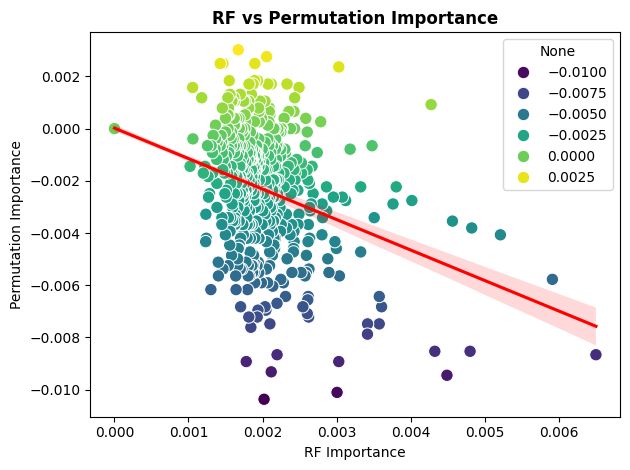

In [15]:
# Visualization 
#1. RF vs. Permutation
plt.figure()
common = base_importance.index.intersection(perm_importance.index)
sns.scatterplot(
    x=base_importance[common],
    y=perm_importance[common],
    hue=perm_importance[common],
    palette="viridis",
    s=80
)
sns.regplot(
    x=base_importance[common],
    y=perm_importance[common],
    scatter=False,
    color="red"
)
plt.title("RF vs Permutation Importance", fontweight='bold')
plt.xlabel("RF Importance")
plt.ylabel("Permutation Importance")
plt.tight_layout()
plt.show()

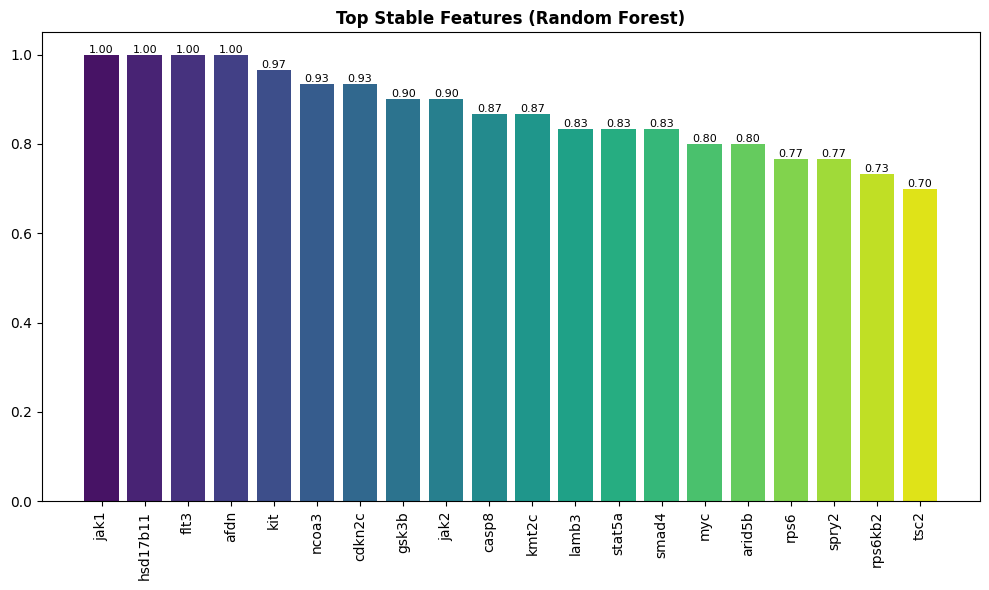

In [52]:
# 2. RF Stability barplot
top20 = frequency_stability.head(20)
colors = sns.color_palette("viridis", len(top20))

plt.figure(figsize=(10,6))
bars = plt.bar(top20.index, top20.values, color=colors)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}",
             ha='center', va='bottom', fontsize=8)

plt.title("Top Stable Features (Random Forest)", fontweight='bold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

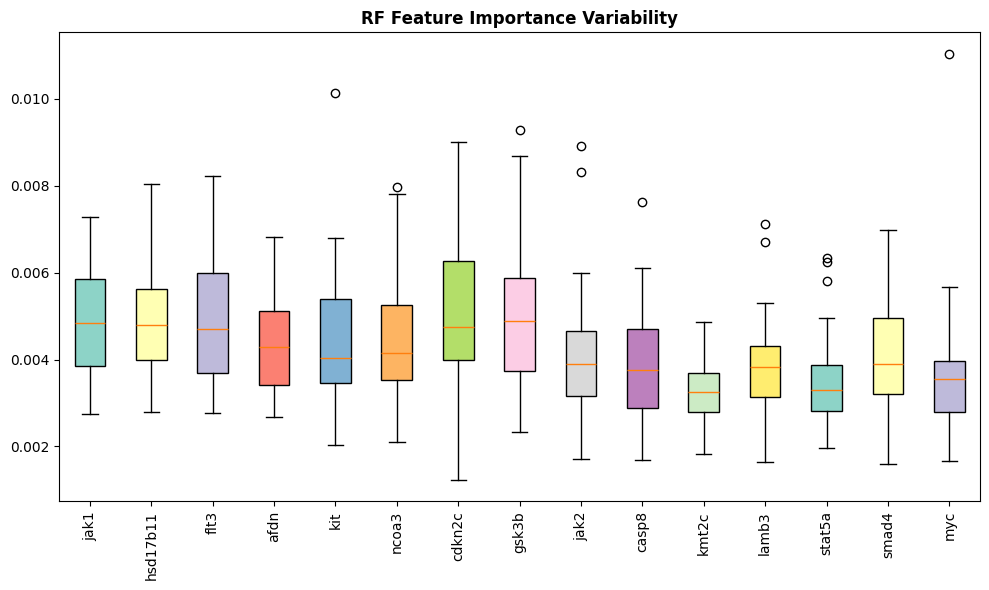

In [53]:
# 3. RF Boxplot Variability
top_genes = frequency_stability.head(15).index

plt.figure(figsize=(10,6))
box = plt.boxplot(
    feature_importances[top_genes].values,
    labels=top_genes,
    patch_artist=True
)

colors = sns.color_palette("Set3", len(top_genes))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title("RF Feature Importance Variability", fontweight='bold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

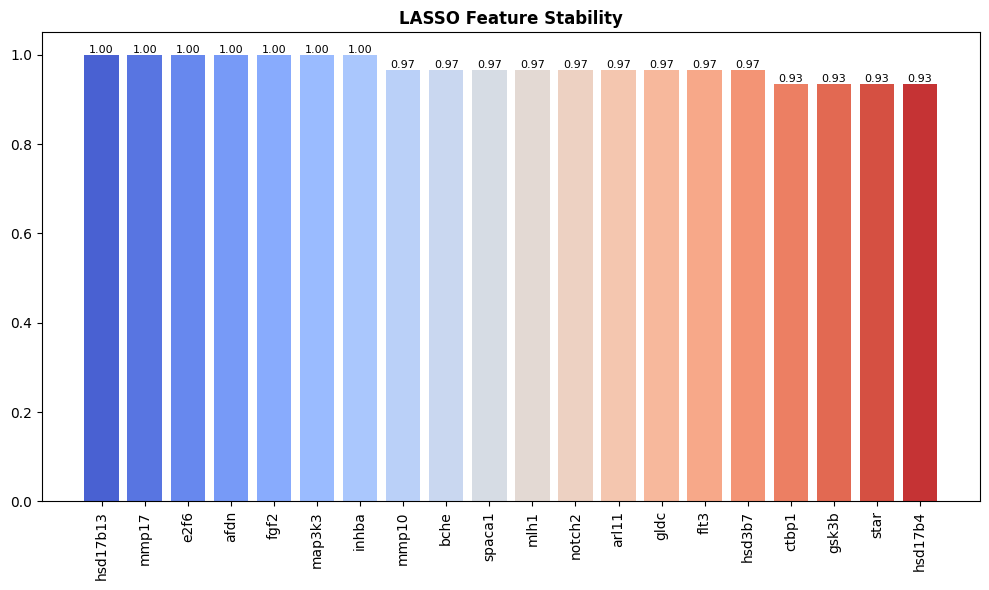

In [55]:
# LASSO Stability
top20_lasso = lasso_frequency.head(20)

plt.figure(figsize=(10,6))
colors = sns.color_palette("coolwarm", len(top20_lasso))

bars = plt.bar(top20_lasso.index, top20_lasso.values, color=colors)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}",
             ha='center', va='bottom', fontsize=8)

plt.title("LASSO Feature Stability", fontweight='bold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

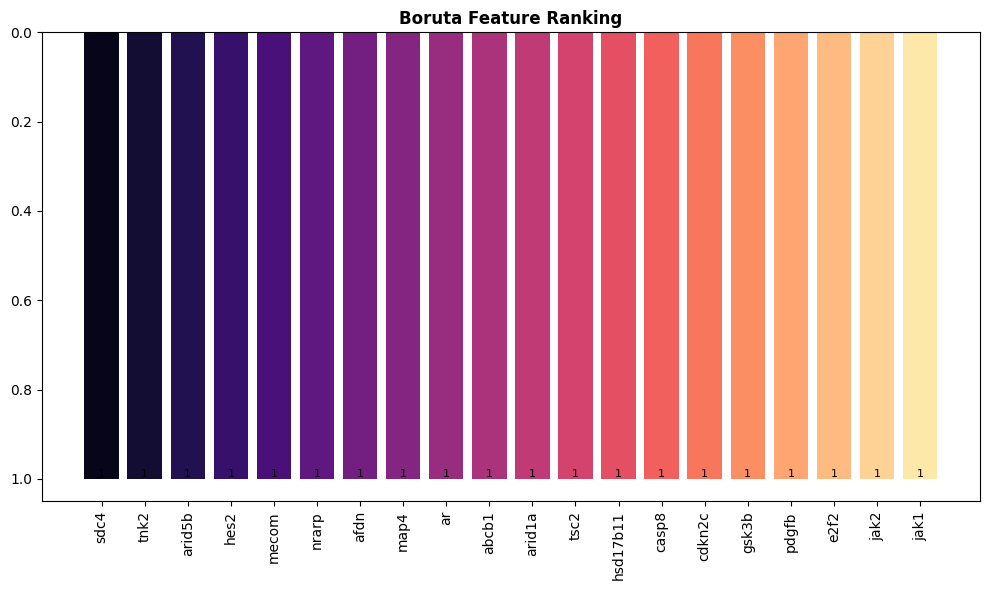

In [56]:
# Boruta
top20_boruta = boruta_rank.head(20)

plt.figure(figsize=(10,6))
colors = sns.color_palette("magma", len(top20_boruta))

bars = plt.bar(top20_boruta.index, top20_boruta.values, color=colors)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.0f}",
             ha='center', va='bottom', fontsize=8)

plt.gca().invert_yaxis()

plt.title("Boruta Feature Ranking", fontweight='bold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


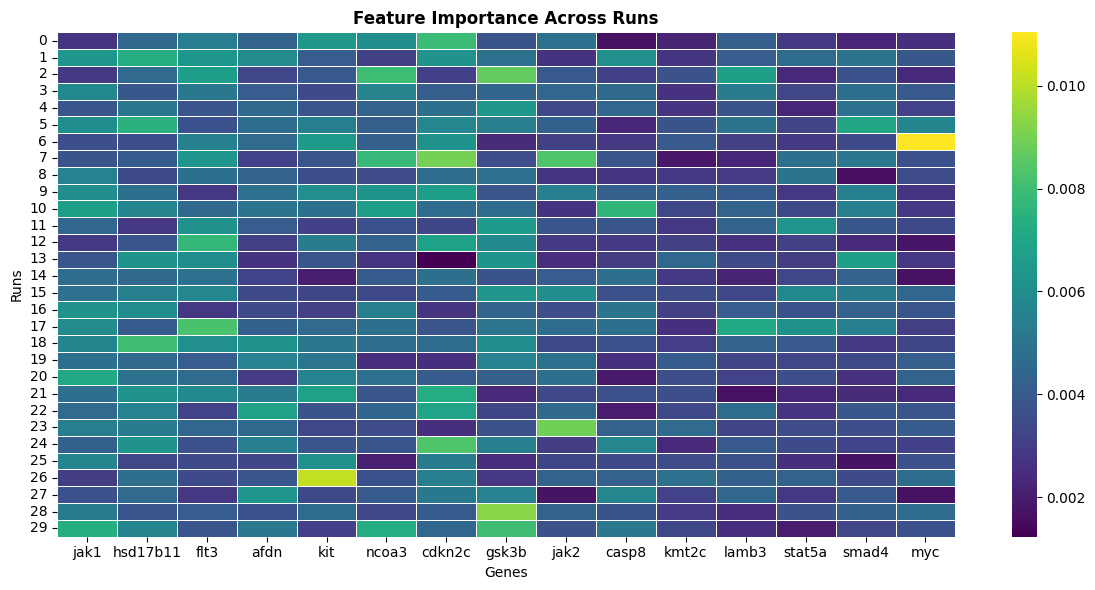

In [57]:
# Heatmap
top_genes = frequency_stability.head(15).index

plt.figure(figsize=(12,6))
sns.heatmap(feature_importances[top_genes],
            cmap="viridis",
            linewidths=0.5)

plt.title("Feature Importance Across Runs", fontweight='bold')
plt.xlabel("Genes")
plt.ylabel("Runs")
plt.tight_layout()
plt.show()

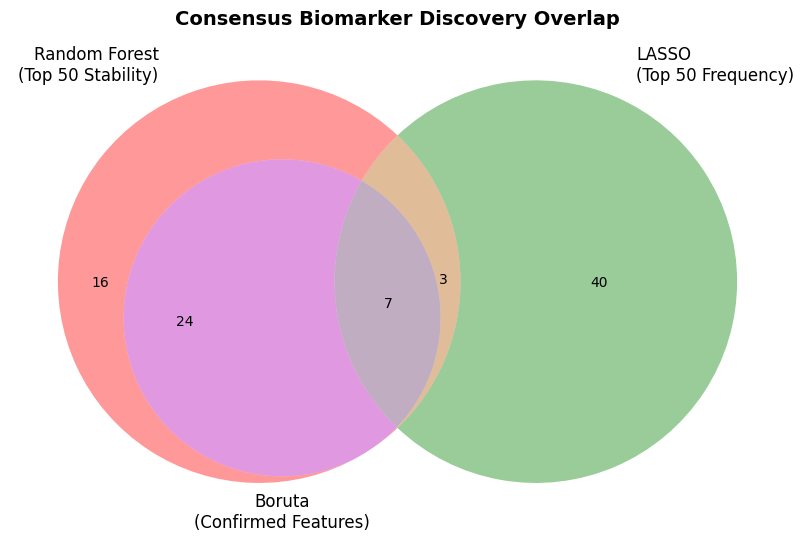

Consensus Core (7 genes):
{'nrarp', 'mecom', 'gsk3b', 'afdn', 'hes2', 'jak2', 'flt3'}


In [ ]:

# For RF and LASSO, we take the top 50 genes based on selection frequency across 30 runs
rf_set = set(frequency_stability.head(50).index)
lasso_set = set(lasso_frequency.head(50).index)

# For Boruta, we take the features the algorithm explicitly "Confirmed"
boruta_set = set(selected_boruta)

plt.figure(figsize=(10, 8))
venn = venn3(
    [rf_set, lasso_set, boruta_set],
    set_labels=('Random Forest\n(Top 50 Stability)', 
                'LASSO\n(Top 50 Frequency)', 
                'Boruta\n(Confirmed Features)')
)

plt.title("Consensus Biomarker Discovery Overlap", fontsize=14, fontweight='bold')
plt.show()

consensus_genes = rf_set.intersection(lasso_set).intersection(boruta_set)
print(f"Consensus Core ({len(consensus_genes)} genes):")
print(consensus_genes)